# Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Import Database

In [3]:
database = 'Ecotoxicity_Database_updated'

# Create DataFrames for each type of properties

In [6]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(f'{database}.xlsx', sheet_name='Polymer_info')

# Experimental conditions DataFrame
df_experimental = pd.read_excel(f'{database}.xlsx', sheet_name='Ecotoxicity_Inputs')

# Ecotoxicity outputs DataFrame
df_ecotox = pd.read_excel(f'{database}.xlsx', sheet_name='Ecotoxicity_Outputs')

In [8]:
# Create final DataFrame
df_final = pd.concat(
    [df_physicochem,
     df_experimental.drop(columns=['Study_id','Instance']),
     df_ecotox.drop(columns=['Study_id','Instance'])],
    axis=1
)

In [10]:
# --- 1) Clean column names ---
def tidy_colnames(cols: pd.Index) -> pd.Index:
    out = (cols
           .str.strip()                              # trim ends
           .str.replace(r'\s+', '_', regex=True)     # internal spaces -> underscore
           .str.replace(r'[^\w]+', '_', regex=True)  # other odd chars -> underscore
           .str.strip('_'))                          # trim underscores
    # ensure uniqueness if collisions happen after cleaning
    seen = {}
    uniq = []
    for c in out:
        if c not in seen:
            seen[c] = 0
            uniq.append(c)
        else:
            seen[c] += 1
            uniq.append(f"{c}__{seen[c]}")
    return pd.Index(uniq)

df_final.columns = tidy_colnames(df_final.columns)

# --- 2) Clean categorical/text columns ---
# object/string columns
for c in df_final.select_dtypes(include=['object', 'string']).columns:
    df_final[c] = df_final[c].str.strip().str.replace(r'\s+', '_', regex=True)

# category dtype columns (rename categories directly)
for c in df_final.select_dtypes(include=['category']).columns:
    df_final[c] = df_final[c].cat.rename_categories(
        lambda x: re.sub(r'\s+', '_', x.strip()) if isinstance(x, str) else x
    )

In [12]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Study_id                     99 non-null     int64  
 1   Instance                     99 non-null     int64  
 2   Monomer_A                    99 non-null     object 
 3   Monomer_B                    29 non-null     object 
 4   Monomer_C                    4 non-null      object 
 5   3HB_ratio                    82 non-null     float64
 6   3HV_ratio                    9 non-null      float64
 7   4HV_ratio                    11 non-null     float64
 8   Mw                           30 non-null     float64
 9   Units_Mw                     18 non-null     object 
 10  Mn                           29 non-null     float64
 11  Units_Mn                     7 non-null      object 
 12  PDI                          37 non-null     float64
 13  Shape                 

In [14]:
# Process Mw, Mn and PDI columns
# PDI = Mw / Mn

mask_Mw = (
    df_final['Mw'].isna() &
    df_final['Mn'].notna() &
    df_final['PDI'].notna()
)

mask_Mn = (
    df_final['Mn'].isna() &
    df_final['Mw'].notna() &
    df_final['PDI'].notna()
)

mask_PDI = (
    df_final['PDI'].isna() &
    df_final['Mw'].notna() &
    df_final['Mn'].notna()
)

df_final.loc[mask_Mw, 'Mw'] = (
    df_final.loc[mask_Mw, 'PDI'] * df_final.loc[mask_Mw, 'Mn']
)

df_final.loc[mask_Mn, 'Mn'] = (
    df_final.loc[mask_Mn, 'Mw'] / df_final.loc[mask_Mn, 'PDI']
)

df_final.loc[mask_PDI, 'PDI'] = (
    df_final.loc[mask_PDI, 'Mw'] / df_final.loc[mask_PDI, 'Mn']
)


In [16]:
# Categorical columns to fill with 'not_applicable'
categorical_cols = ['Additive1_Use', 'Additive2_Use', 'Additive3_Use']

# Numerical columns to fill with 0
numeric_cols = ['Additive1_Percentage', 'Additive2_Percentage', 'Additive3_Percentage', '3HV_ratio', '4HV_ratio']

# Fill categorical columns
for col in categorical_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].fillna('not_applicable').astype(str)

# Fill numerical columns (coerce to numeric, then fill 0)
for col in numeric_cols:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)


In [18]:
unit_period_lst = df_final['Units_Observation_Period'].unique().tolist()
unit_period_lst

['hours', 'days', 'weeks', 'minutes']

In [20]:
to_days = {'minutes': 1/1440, 'hours': 1/24, 'days': 1.0, 'weeks': 7.0}

period = pd.to_numeric(df_final['Observation_Period'], errors='coerce')
factor = df_final['Units_Observation_Period'].map(to_days)
mask   = factor.notna() & period.notna()

# make destination column float to accept fractional days
df_final['Observation_Period'] = pd.to_numeric(df_final['Observation_Period'], errors='coerce').astype('Float64')

df_final.loc[mask, 'Observation_Period']       = (period * factor)[mask]
df_final.loc[mask, 'Units_Observation_Period'] = 'days'

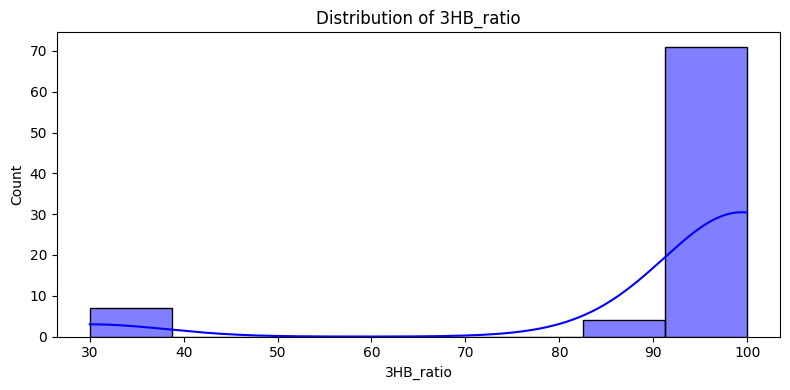

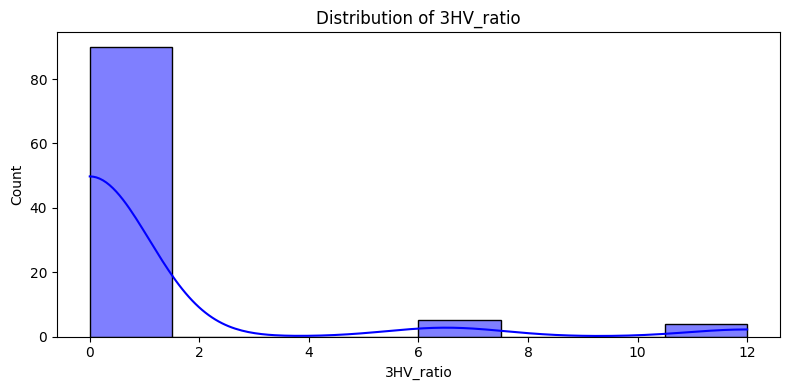

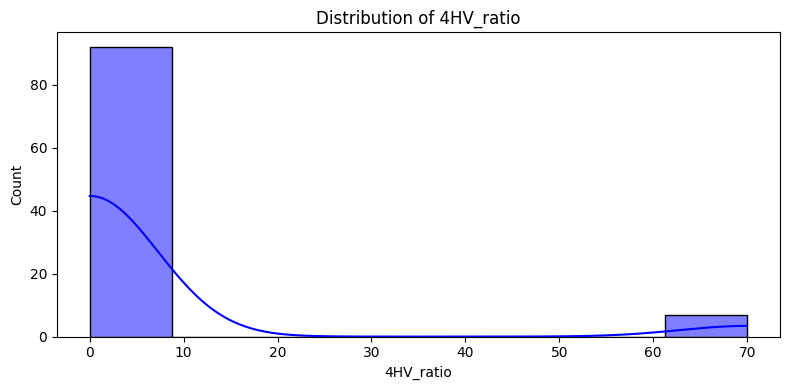

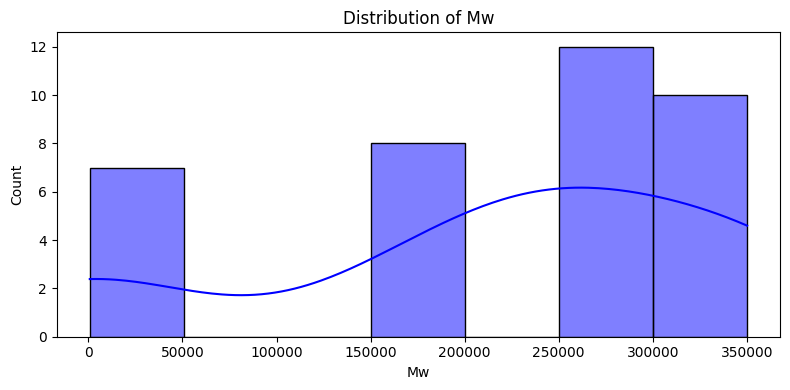

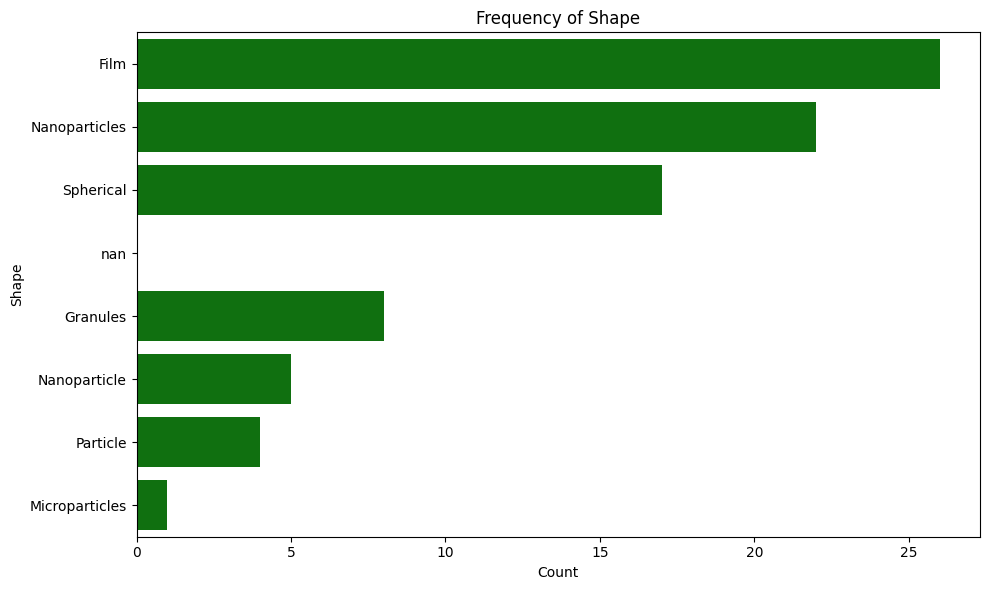

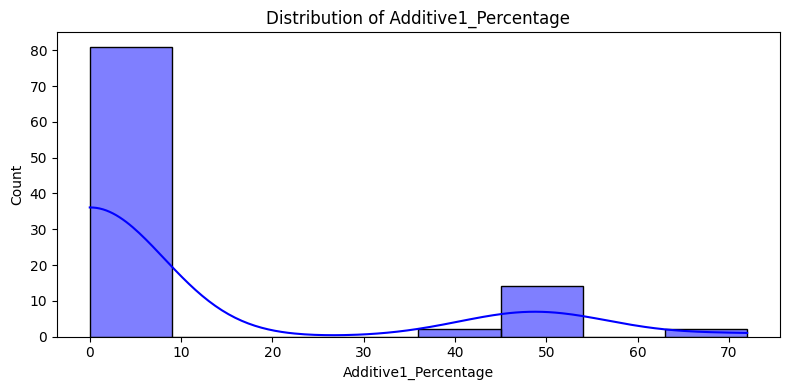

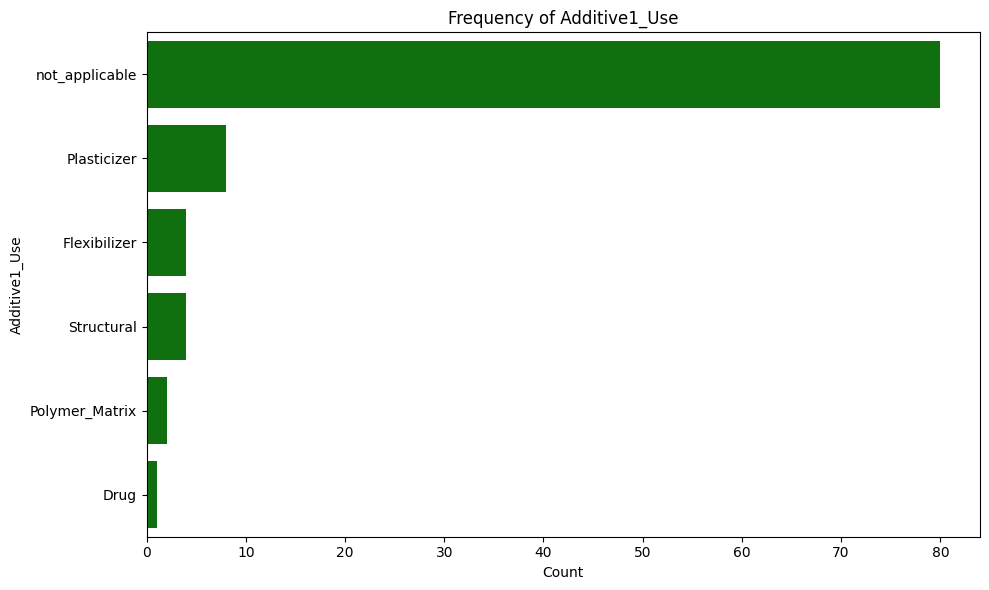

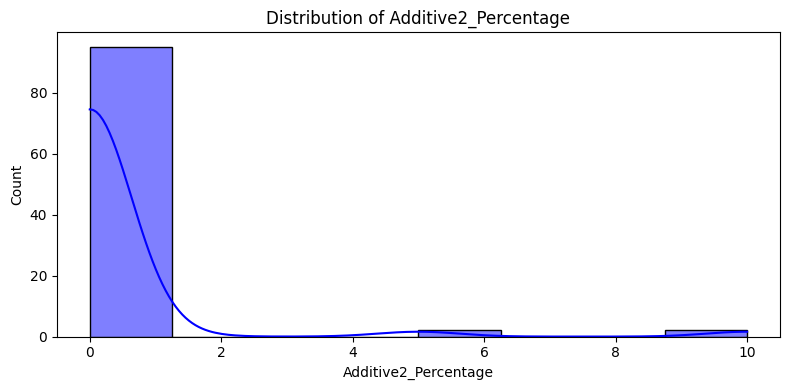

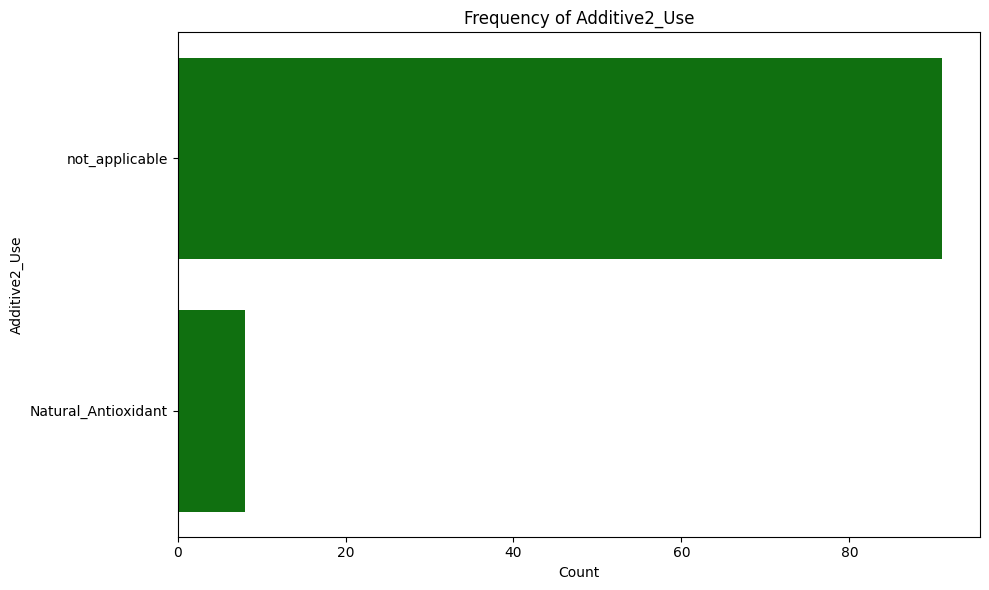

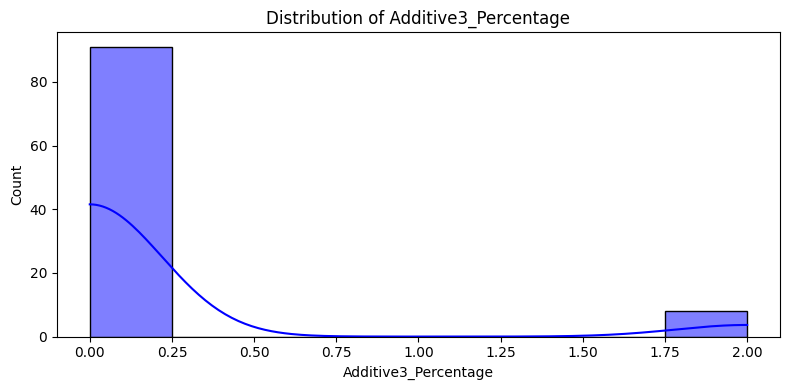

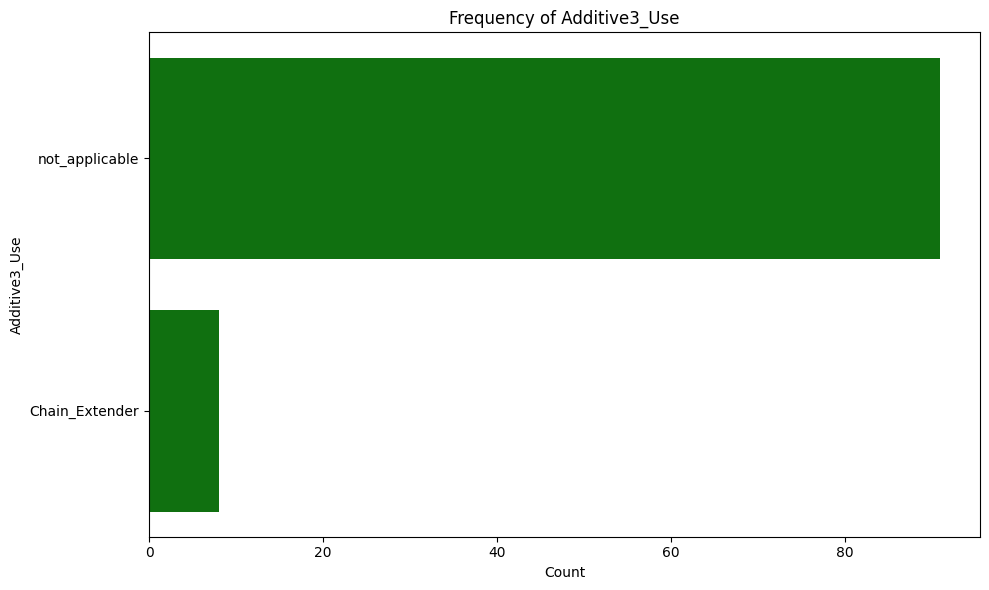

In [22]:
# Make diagrams of distribution for numerical data (blue color) and frequency for categorical data (green color)

diagran_cols = ['3HB_ratio', '3HV_ratio', '4HV_ratio', 'Mw', 'Shape',
                'Additive1_Percentage', 'Additive1_Use',
                'Additive2_Percentage', 'Additive2_Use',
                'Additive3_Percentage', 'Additive3_Use']

for col in diagran_cols:
    if col not in df_final.columns:
        print(f"Skipping missing column: {col}")
        continue

    if pd.api.types.is_numeric_dtype(df_final[col]):
        plt.figure(figsize=(8, 4))
        sns.histplot(df_final[col].dropna(), kde=True, color='blue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
    else:
        # Count unique (including NaN as a separate bar)
        num_categories = df_final[col].nunique(dropna=False)
        fig_height = max(6, num_categories * 0.25)

        plt.figure(figsize=(10, fig_height))
        order = df_final[col].value_counts(dropna=False).index  # sort by frequency
        sns.countplot(y=col, data=df_final, order=order, color='green')
        plt.title(f'Frequency of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()

    plt.show()

In [24]:
# Download final Dataset
df_final.to_csv('ecotoxicity_data.csv', index=False)
